In [ ]:
MY_SECRET_KEY="<YOUR_ROBOFLOW_SECRET_KEY>"

In [ ]:
!pip install ultralytics
!pip install roboflow

In [ ]:
import ultralytics
from roboflow import Roboflow
from ultralytics import YOLO
from IPython.display import Image


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="EVitg097ZJAPOnkIUMkX")
project = rf.workspace("sns-workspace-1whgz").project("continuous_fire-locmi")
version = project.version(1)
dataset = version.download("yolov8")
project = rf.workspace("-jwzpw").project("continuous_fire")
dataset = project.version(6).download("yolov8")

In [11]:
!yolo task=detect mode=train model=yolov8s.pt data="/content/continuous_fire-1/data.yaml" epochs=25 imgsz=640

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/continuous_fire-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

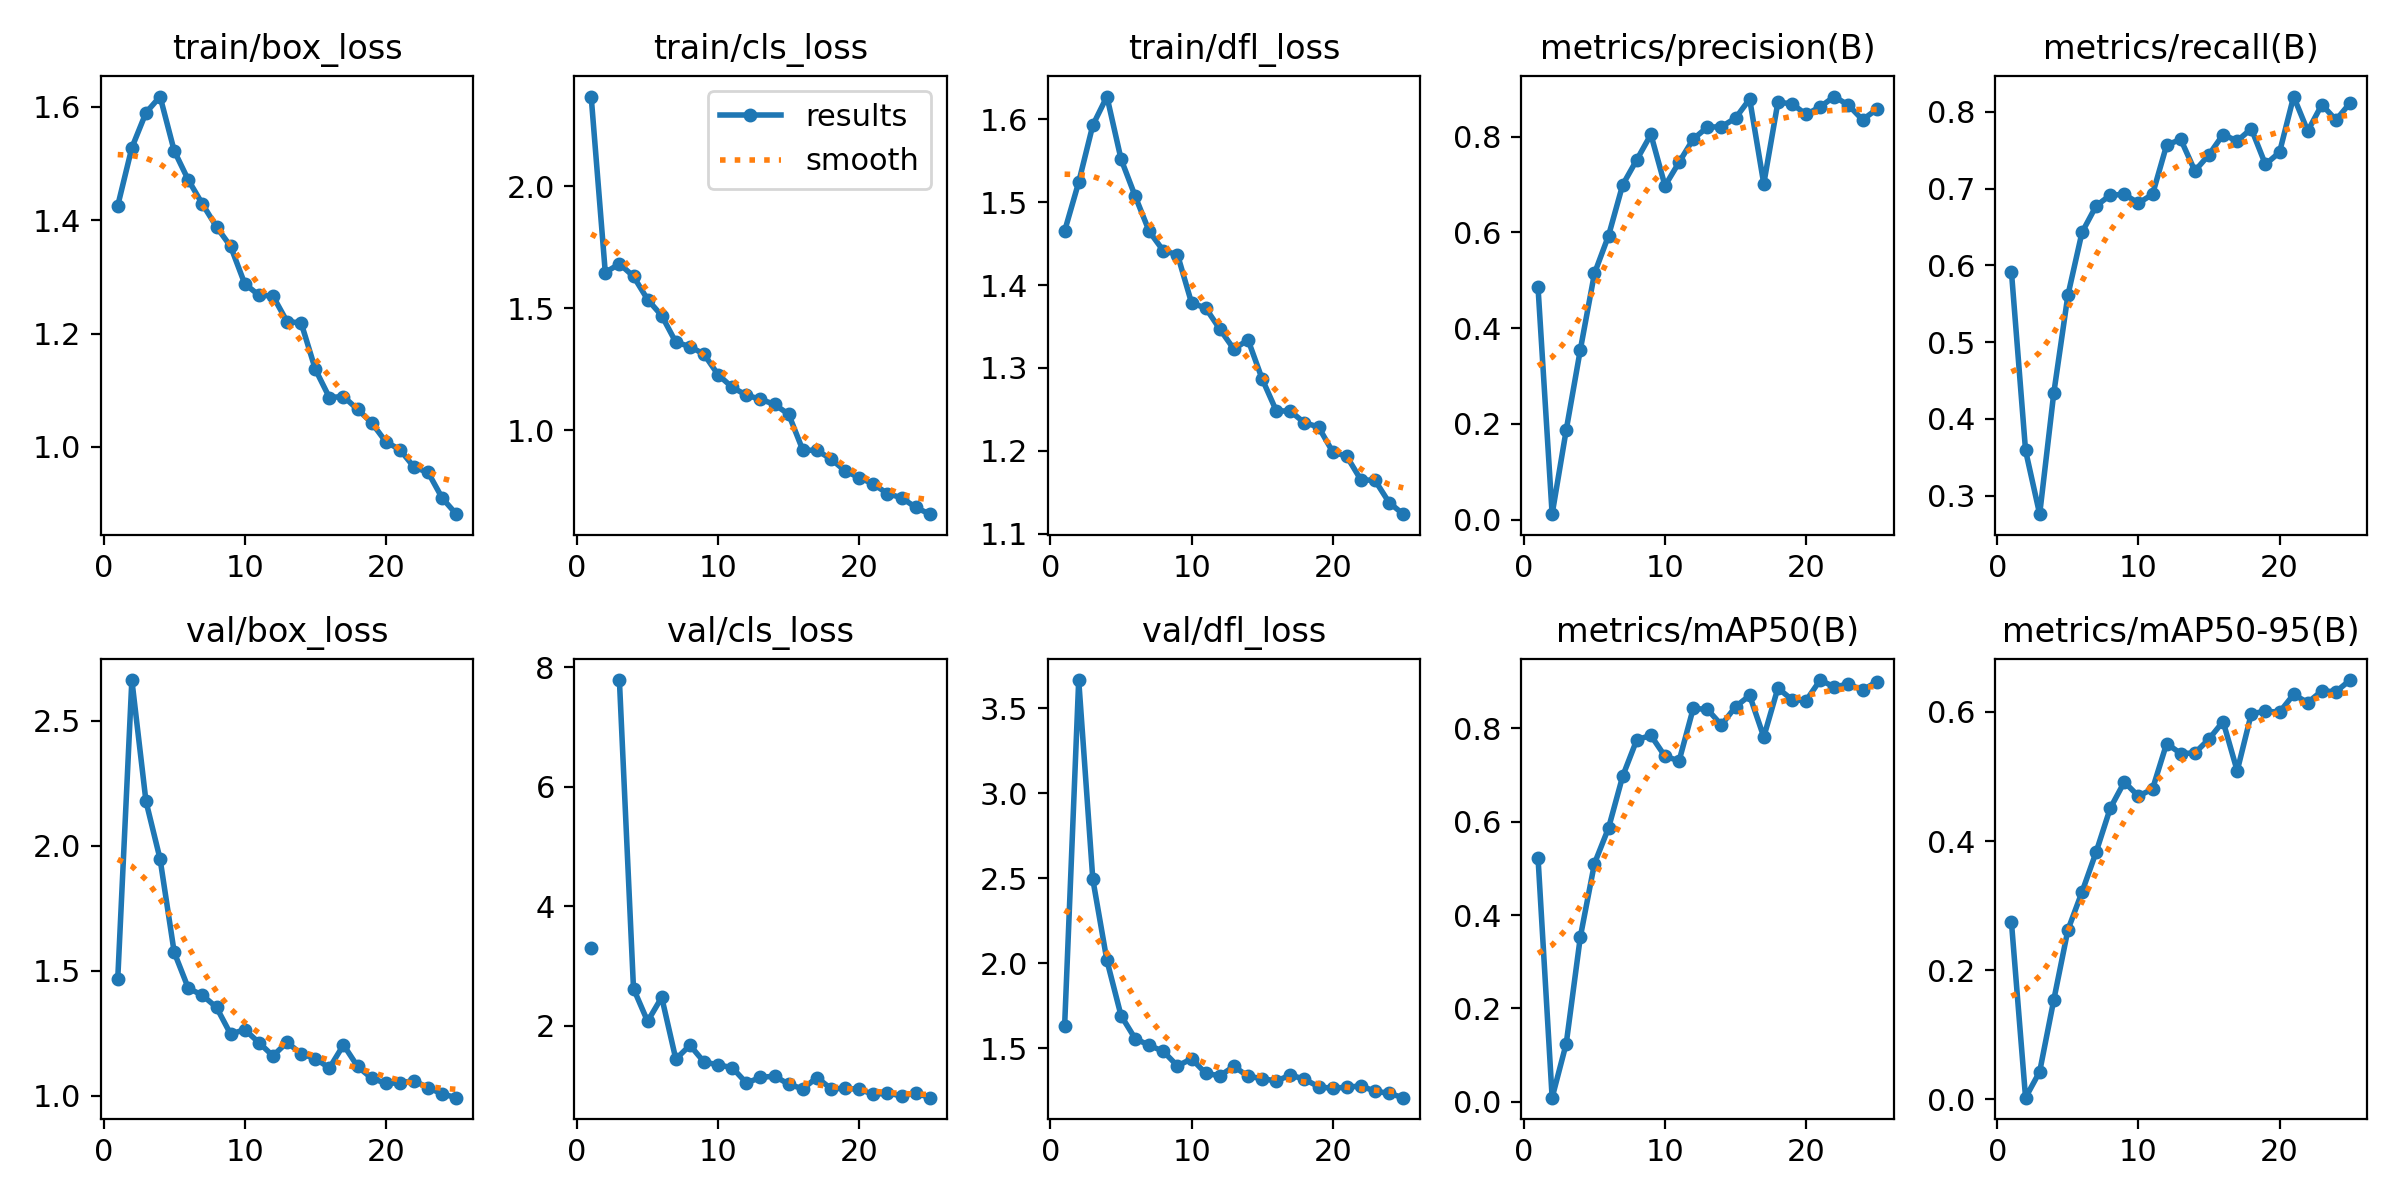

In [13]:
# VIEW MODEL TRANING CHARTS
Image(filename=f'/content/runs/detect/train-2/results.png', width=600)

In [16]:
# VALIDATION
!yolo task=detect mode=val model=/content/runs/detect/train-2/weights/best.pt data=/content/continuous_fire-6/data.yaml

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 293.4±94.5 MB/s, size: 8.9 KB)
val: Scanning /content/continuous_fire-6/valid/labels... 754 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 754/754 2.4Kit/s 0.3s
val: New cache created: /content/continuous_fire-6/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 4.5it/s 10.7s
                   all        754        950      0.863      0.792      0.888      0.634
Speed: 1.4ms preprocess, 8.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val
